# Kaggriculture: notes from replay hunting

I started this notebook as a collection of engine notes. It gradually
turned into a record of how I have been changing my own agent: download
the current leaders, work out which moves repeat, turn the repeatable
part into a local agent, and try to beat it from both seats.

That distinction matters. A replay is one match, not source code. The
losing player may be excellent, and the winner may only have had the
favorable seed or market order. I use both sides as evidence and do not
label every losing action as a mistake.

Kaggriculture is a 720-turn, two-player simulation. The leaderboard is a
skill rating based on wins, losses and ties; a larger coin margin does
not directly buy more rating. Local bank totals and ladder rating answer
different questions.

The first half of the notebook records the mechanics and earlier public
strategy families. Section 4 is the working diary: c14, Hamburger's
market-timing idea, c15/c16, the multi-leader refresh that produced
c18, the public-notebook ablation that produced c27, the horizon sweep
that produced c45/c64, the 9 August refresh that produced c68/C70, and
the 10 August loss audit and tournament that produced C71, the
intraday-capital experiment that produced C72, and the C90-C92 weed
recovery sequence. The fourth-quadrant experiment produced the negative C93 result. The
next live-loss audit then isolated opening feed denial and one-turn
fertilizer preemption; the bounded combination becomes C94.

### Public work I used

| Author / notebook | What I took from it |
| --- | --- |
| [Bovard — Getting Started](https://www.kaggle.com/code/bovard/kaggriculture-getting-started) | Agent contract |
| [Georgy Mamarin — Visualized](https://www.kaggle.com/code/georgymamarin/kaggriculture-visualized-what-every-crop-pays) | Mechanics and market charts |
| [Roman Rozen — Barnyard Economist](https://www.kaggle.com/code/romanrozen/strong-statr-baseline-agent-lb-950) | Melon timing and job-value framing |
| [Roman Tamrazov — Hamburger](https://www.kaggle.com/code/romantamrazov/kaggriculture-hamburger) | Staged mixed herds and clone-aware market timing |
| [Pilkwang Kim — Scenario-Aware](https://www.kaggle.com/code/pilkwang/kaggriculture-scenario-aware-economic-policy) | Economic scheduler lineage |
| [Kun Zhang — C03/C04/C05](https://www.kaggle.com/code/beicicc/kaggriculture-c05-mid-herd-10) | Herd target experiments |
| [prvsiyan — Frontier Lab](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-lab-high-score-visuals) | Cross-play gates |
| Public leaderboard replays | Repeated schedules, opponent responses and market timing |

The notebook embeds the exact candidate used in the final local gate.
Running it creates `main.py` and `submission.tar.gz`; it does not upload
anything by itself.


## 0. Setup

Uses the competition environment from `kaggle-environments` (see the competition data kit `AGENTS.md` / `README.md`).


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

try:
    installed_ke = version("kaggle-environments")
except PackageNotFoundError:
    installed_ke = "0"

# Kaggle's base notebook image may lag the competition runner. The replay-tape
# policies in this notebook require the current Kaggriculture mechanics.
# 1.32.4 is load-bearing, not just "recent": it made BUY_PRODUCT/BUY_SEED fail when
# the shed is at capacity, so a full shed can now silently block feed and starve
# animals. An agent tuned on 1.32.3 can desynchronise on the real runner.
if tuple(map(int, installed_ke.split(".")[:3])) < (1, 32, 4):
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-U", "kaggle-environments>=1.32.4"
    ])

import kaggle_environments
print("kaggle-environments", kaggle_environments.__version__)

from kaggle_environments import make

BOARD, DAYS, TURNS_PER_DAY = 10, 30, 24
EPISODE_STEPS = DAYS * TURNS_PER_DAY  # 720
STARTING_MONEY = 3000


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.9 MB/s eta 0:00:00
kaggle-environments 1.32.6


## 1. The game in one screen

| Knob | Default | Why it matters |
| --- | ---: | --- |
| Turns | 720 (30 x 24) | Long-horizon capital plan |
| Start cash | $3000 | Opening buys compete with each other |
| Land | NE $1k, SW $2k, SE $4k | Top public leaders almost always take **NE+SW**, rarely SE |
| Hire cost | fib(n) per extra hand **today** | First ~10 hands are cheap; 12+ gets expensive fast |
| Shed | 100 non-seed items | Overflow is destroyed — you must sell / liquidate |
| Win | Most **bank** coins | Unsold inventory does **not** count |
| Ladder | Skill rating | **Only** W/L/T; coin margin is irrelevant for Elo |

### Action economy beats the crop table

Each unit (farmer + hired hands) gets **one field op per turn**.  
A high-margin crop that costs two extra walks often loses to a weaker crop next to the shed.

**Rule of thumb:** hiring about 10 hands costs roughly **$143 for a full day** of parallelism. Under-hiring early is usually more expensive than over-hiring inside the cheap Fibonacci region.


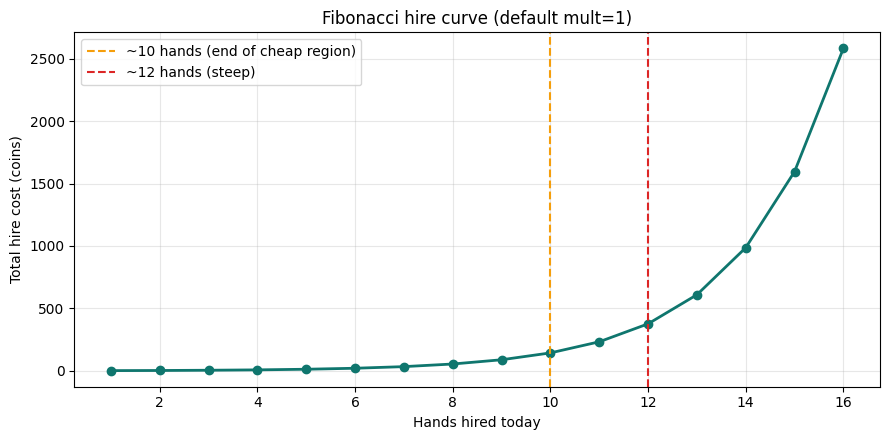

,hands,day_cost
5,6,20
7,8,54
9,10,143
10,11,232
11,12,376
13,14,986


In [2]:
def fib(n):
    a, b = 1, 1
    for _ in range(n):
        a, b = b, a + b
    return a


def hire_day_cost(n_hands):
    # total cost to hire n hands starting from 0 hires today (mult = 1)
    return sum(fib(i) for i in range(n_hands))


ns = np.arange(1, 17)
costs = [hire_day_cost(int(n)) for n in ns]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ns, costs, "o-", lw=2, color="#0f766e")
ax.axvline(10, color="#f59e0b", ls="--", label="~10 hands (end of cheap region)")
ax.axvline(12, color="#dc2626", ls="--", label="~12 hands (steep)")
ax.set(
    xlabel="Hands hired today",
    ylabel="Total hire cost (coins)",
    title="Fibonacci hire curve (default mult=1)",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame({"hands": ns, "day_cost": costs}).query("hands in [6, 8, 10, 11, 12, 14]")


## 2. Engine details that separate weak agents from strong ones

### 2.1 Melon yield window (trust the engine, not only the overview table)

For one-time crops, watering during a bonus window adds yield immediately:

- Melon `max_yield_day = 12` implies window start `ceil(12/2) = 6` → ages **6..12**
- A melon starts at `yield_units = 1`
- Each watered day in-window: **+1** (or **+2** if fertilized)
- Cap is **6**, so full water reaches max around **age 10**, not 12

**16 tiles x 6 = 96 melons** when execution is perfect.  
Missing water on days 6-10 is a common silent leak (for example ~70 units instead of ~96).

### 2.2 `SELL` only sees the shed

- `HARVEST` puts items into the **unit inventory**
- `SELL` spends items from the **shed**

If you harvest 90 melons and never `DROP` while shed-adjacent, the market may not see them until end-of-day auto-drop — often **too late** to fund same-turn land / animal buys.

### 2.3 Fertilizer can be sold

Competition text emphasizes buying fertilizer; the engine's generic `SELL` path still accepts it.  
Each animal generates fertilizer daily → a real sidecar income stream until the market is flooded.

### 2.4 Ladder scoring

Rating updates from **win / loss / tie only**.  
A 140k bank that loses still loses rating. Local mean bank vs `starter` is a useful filter, not the objective.


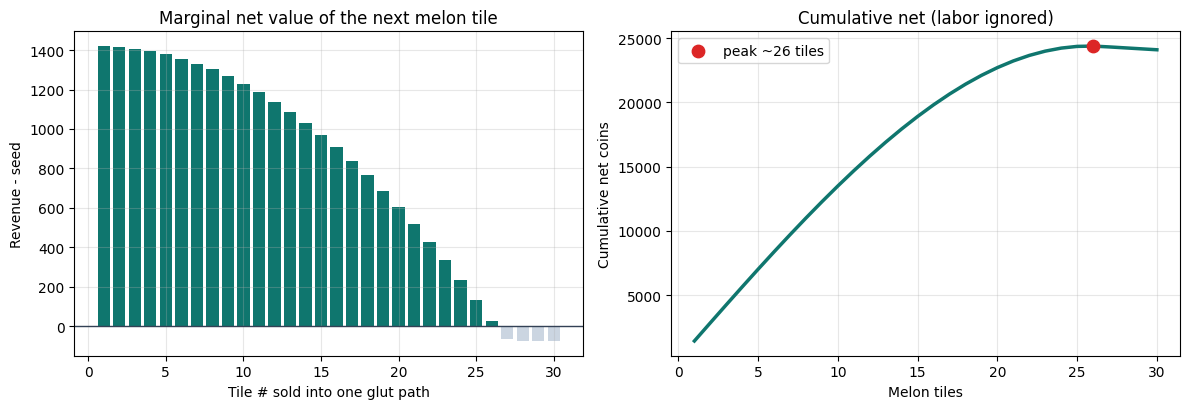

{'illustrative_peak_tiles': 26, 'note': 'Labor and rival sales move the real optimum; public leaders often use ~6-16 melons, not a full 25-tile dump.'}


In [3]:
# Illustrative melon glut curve (public MARKET_PARAMS style, glut side only)
I0, BASE, T = 10000, 250, 300
above_target = 3.6  # melon above_target


def melon_price(inv):
    x = max(0.0, inv - I0)
    amp = above_target * BASE / (T ** 2)
    return max(1, int(round(BASE - amp * x * x)))


units_per_tile = 6
tiles = np.arange(1, 31)
marginal = []
inv = I0
for t in tiles:
    rev = 0
    for _ in range(units_per_tile):
        p = melon_price(inv)
        rev += p
        if p > 1:
            inv += 1
    marginal.append(rev - 80)  # minus seed cost

cum = np.cumsum(marginal)
best = int(tiles[np.argmax(cum)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(tiles, marginal, color=["#0f766e" if v > 0 else "#cbd5e1" for v in marginal])
axes[0].axhline(0, color="#334155", lw=1)
axes[0].set(
    title="Marginal net value of the next melon tile",
    xlabel="Tile # sold into one glut path",
    ylabel="Revenue - seed",
)
axes[1].plot(tiles, cum, lw=2.5, color="#0f766e")
axes[1].scatter([best], [cum[best - 1]], s=80, color="#dc2626", zorder=3, label=f"peak ~{best} tiles")
axes[1].set(title="Cumulative net (labor ignored)", xlabel="Melon tiles", ylabel="Cumulative net coins")
axes[1].legend()
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print({
    "illustrative_peak_tiles": best,
    "note": "Labor and rival sales move the real optimum; public leaders often use ~6-16 melons, not a full 25-tile dump.",
})


## 3. Strategy clusters in the public meta

| Cluster | Opening | Peak farm | Strengths | Failure mode |
| --- | --- | --- | --- | --- |
| **A. Pure cow ranch** | 3-10 cows, little crop | ~10 cows, often NE only | Punishes soft / crop-only bots | Milk wars collapse banks; coin-flip H2H |
| **B. Melon IPO** | 16 melons + 2 cows | Day-10 dump to 12c+8s and 3 quads | Huge capital spike when uncontested | Second melon dumper hits the $1 floor |
| **C. Staged economic herd (C0x)** | **3 cows + 1 sheep** floor | Stages **4 to 8/10 to 14/15** | Strongest *public code* family | Everyone forks it → correlated losses |
| **D. Adaptive leader style** | 3c+1s, ~6 melons | Dynamic cow/sheep/goose mix | Rebalances when milk is contested | Harder to clone cleanly |
| **E. Stable efficiency tape** | Repeated elite trajectory | Tight 8c/6s production and labor schedule | Reproducible across opponents; current best live result | Can become correlated if widely copied |

### Approximate local strength ordering (sandbox H2H)

```text
starter << pure cow << melon IPO << C03 << C05 << Radiant routers << c11/c12/c13 << c14
```

**Caveat:** a bot that prints 100k-170k vs `starter` can still sit mid-ladder, because ladder opponents are other strong farms.


## 4. Replay diary: from c14 to the current multi-leader market meta

### 4.1 The first useful replay rule

My first mistake was treating the winner's tape as the target. That is
too noisy. I now look for three things before copying anything:

1. Does the same field schedule appear against several opponents?
2. Is the market schedule also stable, or is it reacting to the match?
3. Does the distilled tape beat the previous agent from both seats?

The earlier senkin13 refresh passed that test unusually cleanly: the
exact 720-turn field and market schedule appeared in five games. It
ended near 8 cows, 6 sheep and 7 strawberry plots, and became c14 after
I added an observation-driven final-eight-turn cleanup routine.

c14 beat c11, c12 and c13 27-3 each in the paired-seat gate and reached
2182.2 on its standalone ladder run. That was the point where replay
stability became more useful to me than selecting a spectacular single
score.


### 4.2 Hamburger changed the question from *what to build* to *when to sell*

The newer Hamburger notebook did not discover a radically different
mature farm. Its best branch, `Clone Quad H1`, checks whether the two
public farms remain nearly identical. After two close checkpoints it
looks one turn ahead in its own schedule and sells one available
premium line—melon, strawberry, milk or wool—before the expected
shared-market dump.

That is a small wrapper with a large mirror-match effect. Hamburger
reported 6-0 against its anchor, with a mean margin of +1,865.7. I
moved the same one-turn front-run onto the stronger refreshed Senkin
schedule. That hybrid became c15.


In [4]:
c15_gate = pd.DataFrame([
    ["raw refreshed Senkin", 14, 2, 0, 2249.8],
    ["Vlad stable", 9, 7, 0, 725.5],
    ["Hamburger Clone Quad H1", 16, 0, 0, 2083.9],
    ["c14", 16, 0, 0, 2300.2],
    ["Batuhan rank-one replay", 12, 0, 0, 2538.3],
    ["Chloe common tape", 12, 0, 0, 2431.1],
    ["Kenmatsu anchor", 12, 0, 0, 2735.2],
], columns=["opponent", "wins", "losses", "ties", "mean_margin"])
c15_gate


,opponent,wins,losses,ties,mean_margin
0,raw refreshed Senkin,14,2,0,2249.8
1,Vlad stable,9,7,0,725.5
2,Hamburger Clone Quad H1,16,0,0,2083.9
3,c14,16,0,0,2300.2
4,Batuhan rank-one replay,12,0,0,2538.3
5,Chloe common tape,12,0,0,2431.1
6,Kenmatsu anchor,12,0,0,2735.2


The important row is the first one. c15 went 14-2 against the same
refreshed Senkin tape without the wrapper. That convinced me the
timing rule was doing real work rather than merely decorating a
stronger base.

### 4.3 Refreshing the leaders—and catching my own downloader mistake

On 3 August I pulled five replays for each displayed top-five team:

```bash
python scripts/download_top_replays.py --top 5 --per-team 5 \
    --leader-submission-only --force
```

The `--leader-submission-only` part was added after a bad first pass.
Simulation teams can have two active submissions. My original script
merged both episode lists and picked the newest games, which sampled
Tran H Hoang's and Knight of Favonius's newer *lower-rated* agents,
not the submissions responsible for their displayed leaderboard
scores. The corrected run matches `publicScore` to the displayed team
score before choosing episodes.

The leaderboard moved while I was doing this, so the numbers below
are a timestamped snapshot, not permanent ranks.


In [5]:
replay_snapshot = pd.DataFrame([
    [1, "Tran H Hoang", 2858.3, 55203154, 5, 5, "5-0-0", "8c/5s, 5 strawberry, 12 hands"],
    [2, "Knight of Favonius", 2778.8, 55208294, 4, 4, "3-2-0", "8c/5s, 5 strawberry, 12 hands"],
    [3, "VN-Orion", 2735.3, 55207137, 1, 1, "4-1-0", "8c/5s, 5 strawberry, 12 hands"],
    [4, "Superallen001", 2717.9, 55207089, 1, 1, "2-3-0", "8c/5s, 4-5 strawberry, 12 hands"],
    [5, "ömer kiraz", 2700.9, 55210461, 3, 3, "4-0-1", "8c/5s, 5 strawberry, 12 hands"],
], columns=[
    "rank", "team", "rating", "submission_id", "field_variants",
    "market_variants", "sample_record", "mature_farm",
])
replay_snapshot


,rank,team,rating,submission_id,field_variants,market_variants,sample_record,mature_farm
0,1,Tran H Hoang,2858.3,55203154,5,5,5-0-0,"8c/5s, 5 strawberry, 12 hands"
1,2,Knight of Favonius,2778.8,55208294,4,4,3-2-0,"8c/5s, 5 strawberry, 12 hands"
2,3,VN-Orion,2735.3,55207137,1,1,4-1-0,"8c/5s, 5 strawberry, 12 hands"
3,4,Superallen001,2717.9,55207089,1,1,2-3-0,"8c/5s, 4-5 strawberry, 12 hands"
4,5,ömer kiraz,2700.9,55210461,3,3,4-0-1,"8c/5s, 5 strawberry, 12 hands"


The striking result was not one clever move. It was convergence.
All five teams were using versions of the same 8-cow/5-sheep,
12-hand, three-quadrant plan. Many tapes from different teams differed
on only 2-5 field turns and 2-6 market turns. By contrast, this family
differed from c15 on about 226 field turns and 402 market turns.

Tran and Knight had several variants, so I did not use their highest
scoring replay as the new base. VN-Orion repeated one exact full tape
in all five games. Superallen also repeated one tape, and the two
stable versions are only four field turns and three market turns
apart. VN-Orion was the cleaner source for a standalone test.

I kept c15's clone-aware premium front-run and terminal cleanup, but
replaced its base schedule with the stable VN-Orion tape. That is the
c16 candidate below.


In [6]:
c16_gate = pd.DataFrame([
    ["c15", 14, 2, 0],
    ["Hamburger Clone Quad H1", 15, 1, 0],
    ["c14", 11, 1, 0],
    ["Vlad stable", 11, 1, 0],
    ["refreshed Senkin", 11, 1, 0],
    ["Batuhan rank-one replay", 11, 1, 0],
    ["Superallen common-meta tape", 7, 7, 2],
], columns=["opponent", "wins", "losses", "ties"])
c16_gate


,opponent,wins,losses,ties
0,c15,14,2,0
1,Hamburger Clone Quad H1,15,1,0
2,c14,11,1,0
3,Vlad stable,11,1,0
4,refreshed Senkin,11,1,0
5,Batuhan rank-one replay,11,1,0
6,Superallen common-meta tape,7,7,2


The 7-7-2 control is reassuring rather than disappointing: the two
independently sampled common-meta tapes behave like the same policy.
Against the previous families, the new schedule has a clear edge.

### 4.4 Why identical uploads can show very different ratings

I also chased what looked like a packaging bug. The standalone c14
scored 2182.2, while a notebook-produced c14 initially showed 1210.1.
I downloaded the notebook's actual server artifact and compared it
byte for byte. Both `main.py` files had SHA-256
`569cf2d20e3b37c3805c2a4ca7c4e5728eaa85df85c78392cdc3df77c5ddc17b`.

They really were the same agent. Kaggle had simply created a new
rating instance. The standalone copy accumulated 89 public games;
notebook v9 had 26 before it was displaced. While I was checking,
v9 moved from 1210.1 to 1865.6 without a code change. Early opponents,
seeds and seats can put identical copies on very different rating
paths, and only the latest two team submissions continue receiving
games.


### 4.5 A ten-team refresh: the farm stayed fixed, the market moved

The next leaderboard snapshot had Ueddy first at 2847.0 and Tran H
Hoang second at 2821.9. I downloaded 12 public episodes for each of
the top ten teams, restricted to each score-matching active
submission: 120 replay selections in total.

The top ten had converged even more tightly than before. Almost all
mature farms ended near 8 cows, 6 sheep, 3 quadrants and 12 hands,
with 21 melon seeds and 44 strawberry seeds. The useful divergence
was market execution. Ueddy kept the same supply chain but scheduled
materially more premium liquidation than c16.

I distilled all 12 Ueddy traces with the same controller and screened
each against c16. Eleven swept the first 4-game paired-seat gate.
Episode `89746553`, player 1, had the strongest screen margin and
became c18.


In [7]:
premium_sales = pd.DataFrame([
    ["MELON", 146, 172],
    ["MILK", 360, 472],
    ["STRAWBERRY", 394, 505],
    ["WOOL", 241, 297],
], columns=["item", "c16_attempted_sales", "c18_attempted_sales"])

c18_gate = pd.DataFrame([
    ["c11", 10, 0, 14269.7],
    ["c12", 9, 1, 11128.0],
    ["c13", 9, 1, 10654.1],
    ["c14", 9, 1, 6263.7],
    ["c15", 7, 3, 2339.4],
    ["c16", 9, 1, 2794.4],
    ["c17", 9, 1, 2794.4],
], columns=["opponent", "c18_wins", "losses", "mean_margin"])

display(premium_sales)
c18_gate


,item,c16_attempted_sales,c18_attempted_sales
0,MELON,146,172
1,MILK,360,472
2,STRAWBERRY,394,505
3,WOOL,241,297


,opponent,c18_wins,losses,mean_margin
0,c11,10,0,14269.7
1,c12,9,1,11128.0
2,c13,9,1,10654.1
3,c14,9,1,6263.7
4,c15,7,3,2339.4
5,c16,9,1,2794.4
6,c17,9,1,2794.4


The extended c16 gate finished **35-5** over 20 seeds and both
seats, with a +3,161.3 mean margin and no errors. Representative
tapes from the other refreshed leaders were also screened directly.
Anton's was the only close challenger; c18 won their extended
20-seed match 23-17, so c18 was preferred for head-to-head
reliability.

c18 changes only 20 pre-terminal field turns from c16 but 112 market
turns. This is the clearest evidence in the diary that the current
edge comes from inventory-sale timing rather than another change in
herd composition.


### 4.6 Three public notebooks and one terminal-timing correction

I then compared three newer public notebooks directly:

- Navaz's notebook restores Tran H Hoang episode `89674601`;
- Hamburger V27 uses that exact same source as its anchor and tests
  SELL-slot ordering plus terminal inventory relays;
- Kaito V18 selects complete market experts once per day using
  public-state distance, seat priors and hysteresis.

Navaz/Tran and Hamburger's anchor have the same SHA-256, so they are
one base strategy rather than two independent confirmations. Kaito
was the strongest import and beat c20, Navaz and Hamburger 18-2
each, but c17 still beat Kaito 17-3.

Field/market swaps were informative but did not promote. Kaito's
field with c17's market was competitive, while Kaito's market on a
mismatched field was weaker. A seat router also remained just below
c17. The transferable Hamburger finding was more mechanical: step
718 executes, while action index 719 does not.

c17's terminal field controller had taken over at step 712. Delaying
it to 717 preserves five more turns of the locally stronger tape and
still leaves steps 717 and 718 for terminal cleanup. This one-line
correction became c27.


In [8]:
c27_gate = pd.DataFrame([
    ["c17 Market Common", 13, 7, 0, 42.0],
    ["c20 Rank-One Medoid", 20, 0, 0, 5226.8],
    ["Navaz / Tran 89674601", 19, 1, 0, 3558.9],
    ["Kaito V18 Closed Loop", 19, 1, 0, 3559.8],
    ["Hamburger V27 experimental", 19, 1, 0, 4157.1],
], columns=["opponent", "c27_wins", "losses", "ties", "mean_margin"])
c27_gate


,opponent,c27_wins,losses,ties,mean_margin
0,c17 Market Common,13,7,0,42.0
1,c20 Rank-One Medoid,20,0,0,5226.8
2,Navaz / Tran 89674601,19,1,0,3558.9
3,Kaito V18 Closed Loop,19,1,0,3559.8
4,Hamburger V27 experimental,19,1,0,4157.1


The fresh promotion gate finished **90-10**, using ten untouched
seeds, both seats and the official 1.32.2 engine, with no runtime
errors. This remains local evidence rather than a leaderboard-score
claim. More importantly, it came from a falsifiable engine detail
and survived direct comparison with the previous best.


### 4.7 The horizon arms race and the 9 August field refresh

By 8 August, 11 of the top 12 teams had converged on a
three-quadrant field ending near 8 cows, 6 sheep, 23 strawberries
and 31 wheat tiles. C45 kept that route but shifted eligible premium
sales two turns earlier, recording a debt so the original later sale
was reduced by exactly the shifted quantity. It reached 3085.4 and
rank 9 in the first live snapshot.

A sweep through horizon 28 was a useful warning. Horizon 25 won the
restricted long-horizon finalist gate, but then lost 0-6 to C45,
unmodified V14 and several shorter horizons on fresh seeds. Its live
score also finished below C45. Aggregate wins against weak historical
agents had hidden the strategically important parent regression.

On 9 August I downloaded ten scoring-submission replays from each of
the live top 20 teams: 200 selections. A single field hash appeared
in 144 episodes from 40 teams. Most ranks 3-20 were 99-100% identical
on field actions, and their recorded market decisions fit horizon 3
best. The real alternatives were Seb, HealthStone and THUNDER;
THUNDER's wheat-heavy route was the strongest in local cross-play.


In [9]:
refreshed_meta = pd.DataFrame([
    ["dominant common route", 40, 144, "~8c/6s, 23 strawberry, 31 wheat", "mostly horizon 3"],
    ["Seb family", 1, 10, "four quadrants, adaptive livestock", "distinct"],
    ["HealthStone family", 1, 10, "wheat-heavy, adaptive herd", "distinct"],
    ["THUNDER family", 1, 10, "wheat-heavy alternative", "strongest local exception"],
], columns=["family", "teams_seen", "episodes", "mature_field", "market_note"])

c68_gates = pd.DataFrame([
    ["focused frozen-candidate screen", "850000-850009", 253, 7, 0],
    ["all 60 refreshed top-replay reconstructions", "860000-860004", 622, 8, 0],
    ["untouched final block", "900000-900019", 342, 18, 0],
], columns=["gate", "seeds", "wins", "losses", "errors"])

display(refreshed_meta)
c68_gates


,family,teams_seen,episodes,mature_field,market_note
0,dominant common route,40,144,"~8c/6s, 23 strawberry, 31 wheat",mostly horizon 3
1,Seb family,1,10,"four quadrants, adaptive livestock",distinct
2,HealthStone family,1,10,"wheat-heavy, adaptive herd",distinct
3,THUNDER family,1,10,wheat-heavy alternative,strongest local exception


,gate,seeds,wins,losses,errors
0,focused frozen-candidate screen,850000-850009,253,7,0
1,all 60 refreshed top-replay reconstructions,860000-860004,622,8,0
2,untouched final block,900000-900019,342,18,0


C68 combines the strongest refreshed THUNDER public field tape
(episode `91211393`, player 0) with a new market controller. The
controller observes premium-product market inventory changes,
removes its own sale and deterministic town drain, fits the
opponent's extra batches to horizons 1-6, and races one turn ahead.
It defaults to horizon 4 until enough evidence arrives.

This is narrower than C64's fixed horizon 25: it moves only as far
as the observed near-clone race requires. In diagnostics it correctly
identified horizons 2, 3, 4 and 5. The classifier is gated by public
farm similarity, so unrelated field families keep the base schedule.

The field tape is explicitly competitor-derived public replay data;
the online horizon inference is the original contribution. C68 was
frozen before the final block, finished **342-18** there with zero
errors, and was submitted as `55371099`.


### 4.8 Why C70 stalled below 3000, and the search that produced C71

C70 was not broken. I downloaded all 88 public episodes from its
live submission `55389625`, reconstructed the recorded opponents,
and verified the submitted agent action-for-action on 2,157 sampled
observations. It finished every game and went **83-5** with a
+14,196 mean margin. Its five losses were narrow against Jince, WBF,
Gould and Pranjal, plus one larger Ueddy loss.

That explains the rating plateau: Kaggle rating rewards wins, not
surplus coins. C70 already crushed weaker agents, while its rigid
route and largely fixed sell timing failed to convert the few close
games that mattered. Increasing margins against agents it already
beat could not reliably move a sub-3000 rating.

I reconstructed current public top-agent trajectories and screened
26 field/market combinations. Several routes fixed one historical
loss but regressed badly across the wider field. The useful change
was narrower: keep the proven route family, use market timing from
GiovanniCR episode `91533875` player 0, then sort premium SELLs by
estimated self-induced price impact. MELON, STRAWBERRY, MILK and
WOOL may move ahead of competing market dumps; WHEAT and FERTILIZER
retain safer timing because opponents can buy them.

This candidate became **C71 Giovanni Impact**. The replay-derived
backbone remains attributed to GiovanniCR. The reconstruction and
impact-ordering overlay are the contribution documented here.


In [10]:
c71_validation = pd.DataFrame([
    ["88 historical live opponents", "C70", "83-5", 14196, None],
    ["88 historical live opponents", "C71", "83-5", 14523, None],
    ["shared 39-agent holdout + direct", "C70", "341-56-3", None, 1953],
    ["shared 39-agent holdout + direct", "C71", "354-46", None, 1996],
    ["untouched four-agent round robin", "C70", "57-63", 81, 1487],
    ["untouched four-agent round robin", "C71", "83-37", 404, 1605],
    ["untouched direct matchup", "C71 vs C70", "31-9", 231, None],
], columns=["test", "agent", "record", "mean_margin", "Bradley_Terry"])
c71_validation


,test,agent,record,mean_margin,Bradley_Terry
0,88 historical live opponents,C70,83-5,14196.0,NaN
1,88 historical live opponents,C71,83-5,14523.0,NaN
2,shared 39-agent holdout + direct,C70,341-56-3,NaN,1953.0
3,shared 39-agent holdout + direct,C71,354-46,NaN,1996.0
4,untouched four-agent round robin,C70,57-63,81.0,1487.0
5,untouched four-agent round robin,C71,83-37,404.0,1605.0
6,untouched direct matchup,C71 vs C70,31-9,231.0,NaN


C71 ranked first in the untouched round robin and made zero runtime
errors. It beat C70 **31-9**, Nikita **25-15**, and the Ezz
alternative **27-13**. A separate broad holdout also preferred C71:
Bradley–Terry 1996 versus 1953 for C70.

The negative result is just as important. On the 88 historical live
episodes C71 improved mean margin by only +327 and converted none of
C70's five losses. Those games are an in-sample diagnostic, not a
forecast of a higher Kaggle score. Promotion rests on the fresh
holdouts; C71 has deliberately **not** been submitted at the time of
this notebook update.


### 4.9 C72: bank only the large load that is already beside the shed

A later replay against Aleks Lviv exposed a different opportunity.
Aleks briefly held roughly 4,000 more coins than C71. Copying the
whole irregular route did not transfer, and aggressive continuous
liquidation was much worse. The useful hypothesis was narrower:
some premium inventory could become working capital sooner without
disrupting the proven farm schedule.

I wrapped C71 with a protected logistics rule. From steps 120-679 it
may replace only `PASS` or movement—never planting, watering,
harvesting, feeding, collecting or care. A worker is diverted only
when carrying at least 2,000 coins of melon, strawberry, milk or wool
at current prices and already at most one move from a center-shed
access tile. On deposit, a sufficiently priced premium sale is moved
forward in the market queue.

This cutoff was sharp. No-diversion sale promotion, thresholds of
500 or 1,000, and every two-step diversion lost 0-8 to both C70 and
C71. Only the one-step, 2,000-value rule survived. Across ten
liquidity games it caused just 16 extra actor drops: 1.6 per game.


In [11]:
c72_threshold_gate = pd.DataFrame([
    ["d0_v1000", "0 steps / value 1000", "0-8", "0-8"],
    ["d1_v500",  "1 step / value 500",  "0-8", "0-8"],
    ["d1_v1000", "1 step / value 1000", "0-8", "0-8"],
    ["d2_v1000", "2 steps / value 1000", "0-8", "0-8"],
    ["d2_v2000", "2 steps / value 2000", "0-8", "0-8"],
    ["d1_v2000", "1 step / value 2000", "7-1", "7-1"],
], columns=["variant", "banking trigger", "vs C70", "vs C71"])

c72_validation = pd.DataFrame([
    ["day 15 liquidity", "9/10 positive", 208.9, "liquid-value delta"],
    ["15-opponent broad gate", "109-11", 5224.8, "120 games"],
    ["untouched vs C70", "29-11", 1352.7, "20 seeds, both seats"],
    ["untouched vs C71", "27-13", 1197.2, "20 seeds, both seats"],
    ["88 historical live tapes", "84-4", 24291.6, "fixed-tape diagnostic"],
], columns=["test", "result", "mean_delta_or_margin", "note"])

display(c72_threshold_gate)
c72_validation


,variant,banking trigger,vs C70,vs C71
0,d0_v1000,0 steps / value 1000,0-8,0-8
1,d1_v500,1 step / value 500,0-8,0-8
2,d1_v1000,1 step / value 1000,0-8,0-8
3,d2_v1000,2 steps / value 1000,0-8,0-8
4,d2_v2000,2 steps / value 2000,0-8,0-8
5,d1_v2000,1 step / value 2000,7-1,7-1


,test,result,mean_delta_or_margin,note
0,day 15 liquidity,9/10 positive,208.9,liquid-value delta
1,15-opponent broad gate,109-11,5224.8,120 games
2,untouched vs C70,29-11,1352.7,"20 seeds, both seats"
3,untouched vs C71,27-13,1197.2,"20 seeds, both seats"
4,88 historical live tapes,84-4,24291.6,fixed-tape diagnostic


On day 15 C72 averaged +168.5 cash and +208.9 liquid value versus
C71, with a positive liquid edge in 9 of 10 games. This is a reliable
few-hundred-coin improvement, not a reproduction of Aleks's 4,000
coin spike.

The final evidence was stronger than the small screen: **109-11**
against 15 representative reconstructed agents, then **29-11**
against C70 and **27-13** against C71 on 20 untouched seeds in both
seats. There were zero runtime errors. On the same 88 historical
live-opponent tapes used in the C70/C71 audit it went **84-4**, with
+24,291.6 mean margin and 93,615.6 mean bank. Fixed opponent tapes
are correlated diagnostics, so promotion rests on the fresh gates.

The transferable lesson is not “sell constantly.” It is: interrupt
logistics only for a large premium load whose banking cost is almost
free. C72 remains a local experiment and has **not** been submitted.


In [12]:
openings = pd.DataFrame([
    {"name": "Pure cow open", "melon_seeds": 0, "cows": 3, "sheep": 0, "notes": "expand cows later"},
    {"name": "Melon IPO open", "melon_seeds": 16, "cows": 2, "sheep": 0, "notes": "dump around day 10"},
    {"name": "C0x / radiant open", "melon_seeds": 6, "cows": 3, "sheep": 1, "notes": "mixed option value"},
    {"name": "Nishchal-like open", "melon_seeds": 9, "cows": 4, "sheep": 0, "notes": "early dairy density"},
])
openings["seed_cost"] = openings.melon_seeds * 80
openings["animal_cost"] = openings.cows * 400 + openings.sheep * 500
openings["rough_spend"] = openings.seed_cost + openings.animal_cost
openings["cash_left_from_3000"] = STARTING_MONEY - openings.rough_spend
openings


,name,melon_seeds,cows,sheep,notes,seed_cost,animal_cost,rough_spend,cash_left_from_3000
0,Pure cow open,0,3,0,expand cows later,0,1200,1200,1800
1,Melon IPO open,16,2,0,dump around day 10,1280,800,2080,920
2,C0x / radiant open,6,3,1,mixed option value,480,1700,2180,820
3,Nishchal-like open,9,4,0,early dairy density,720,1600,2320,680


## 5. Live mini-simulations

### 5.1 Environment smoke test


In [13]:
def run_pair(a="starter", b="starter", seed=0, steps=720):
    env = make("kaggriculture", configuration={"episodeSteps": steps, "seed": seed}, debug=False)
    env.run([a, b])
    final = env.steps[-1]
    return {
        "seed": seed,
        "r0": final[0].reward,
        "r1": final[1].reward,
        "s0": str(final[0].status),
        "s1": str(final[1].status),
    }

pd.DataFrame([run_pair("starter", "random", seed=s) for s in range(3)])


,seed,r0,r1,s0,s1
0,0,3455.0,0.0,DONE,DONE
1,1,3455.0,0.0,DONE,DONE
2,2,3476.0,0.0,DONE,DONE


### 5.2 Built-in baseline matrix

Expect `starter` to beat `random` and `pass` on average. Your bot should crush `starter` locally before you overfit the public leaderboard number.


In [14]:
rows = []
for a, b in [("starter", "random"), ("starter", "pass"), ("random", "pass")]:
    for seed in range(2):
        rows.append({"a": a, "b": b, **run_pair(a, b, seed=seed)})
pd.DataFrame(rows)


,a,b,seed,r0,r1,s0,s1
0,starter,random,0,3498.0,0.0,DONE,DONE
1,starter,random,1,3455.0,0.0,DONE,DONE
2,starter,pass,0,3455.0,3000.0,DONE,DONE
3,starter,pass,1,3490.0,3000.0,DONE,DONE
4,random,pass,0,0.0,3000.0,DONE,DONE
5,random,pass,1,0.0,3000.0,DONE,DONE


## 6. The build ladder I actually followed

I began with agents that merely survived validation, then moved through
pure cows, a melon capital event, staged mixed herds and public tape
routers. The last four steps mattered most:

- **c14:** choose a full schedule only after it repeats across opponents;
- **c15:** keep the schedule but front-run a clone's premium sale by one turn;
- **c16:** refresh the base when several leaders converge on a demonstrably
  stronger operating plan.
- **c18:** hold the common farm fixed and promote the premium market
  schedule that survives a ten-team replay screen.
- **c27:** preserve c17's strong market route but move terminal field
  control from step 712 to the verified final window at step 717;
- **c45:** preserve the converged route and shift premium clone sales by
  a conservative, debt-tracked two turns;
- **c68/c70:** refresh to THUNDER and use observation-driven or
  price-impact market ordering;
- **c71:** keep the proven route family, replace its market trace with
  the GiovanniCR public reconstruction, and promote premium sells by
  estimated price impact after a broad reconstruction tournament.
- **c72:** preserve C71's productive actions and bank only premium loads
  worth at least 2,000 when the shed costs no more than one move.

Every promotion used both seats. I keep the previous agent as an opponent
and add at least one unrelated public family. A high bank against
`starter` is a smoke test, not a promotion test.


## 7. Common bugs (high frequency)

| Bug | Symptom | Fix |
| --- | --- | --- |
| CARE ranked above melon WATER | Day 9 waters only part of the field; yield ~70 not ~96 | Water priority first in ages 6-12 |
| No DROP after HARVEST | Produce stuck in unit inventory; IPO underfunded | DROP when carrying melon/milk stacks |
| Dig melon tiles for pastures too early | Destroy fruit before harvest | Protect valuable melons until sold |
| Buy many cows day 0 with no feed reserve | Animals escape by day 2 | Reserve wheat cash before animal spam |
| Fixed 10 cows forever | Mirror banks collapse toward ~40k | Add sheep/strawberry/opponent routing |
| Optimize only mean bank vs starter | High local bank, mediocre Elo | H2H vs strong bots, both seats |
| Two near-identical active submits | Meta shift kills both | Diversify the second slot |


## 8. Local evaluation protocol

```text
1. Compile/import the exact packaged main.py
2. Self-play validation: both agents must finish DONE
3. Play the incumbent and the unmodified parent on disjoint seeds, both seats
4. Treat a loss to either as a veto, even if aggregate wins look strong
5. Play several genuinely different public field families
6. Report per-opponent records, not only the aggregate
7. Freeze all parameters, then run one untouched final seed block
8. Audit cash, feed, animal survival, shed overflow and runtime
9. Keep the result files, including losses
10. Only then build an archive
```

Shared-market games are not symmetric. A one-seat test can reverse the
apparent winner.


In [15]:
def h2h(agent_a, agent_b, seeds=range(3), both_seats=True):
    """Quick head-to-head helper. agent_* may be callables or built-in names."""
    seats = (0, 1) if both_seats else (0,)
    rows = []
    for seed in seeds:
        for seat in seats:
            env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": int(seed)})
            order = [agent_a, agent_b] if seat == 0 else [agent_b, agent_a]
            env.run(order)
            final = env.steps[-1]
            r0, r1 = final[0].reward, final[1].reward
            me, opp = (r0, r1) if seat == 0 else (r1, r0)
            rows.append({
                "seed": seed,
                "seat": seat,
                "me": me,
                "opp": opp,
                "win": me > opp,
                "status0": str(final[0].status),
                "status1": str(final[1].status),
            })
    df = pd.DataFrame(rows)
    summary = {
        "games": len(df),
        "wins": int(df.win.sum()),
        "win_rate": float(df.win.mean()),
        "mean_bank": float(df.me.mean()),
        "mean_opp": float(df.opp.mean()),
    }
    return df, summary


# Example using built-ins only (swap in your agent callables locally)
df, summary = h2h("starter", "random", seeds=range(2))
print(summary)
df


{'games': 4, 'wins': 4, 'win_rate': 1.0, 'mean_bank': 3480.75, 'mean_opp': 0.0}


,seed,seat,me,opp,win,status0,status1
0,0,0,3500.0,0.0,True,DONE,DONE
1,0,1,3484.0,0.0,True,DONE,DONE
2,1,0,3455.0,0.0,True,DONE,DONE
3,1,1,3484.0,0.0,True,DONE,DONE


## 9. The strategy history in one line

```text
melon tutorials -> cow ranches -> staged mixed herds -> economic schedulers
  -> larger target herds -> tape routers -> stable c14 efficiency schedule
    -> c15 clone-aware sale timing -> c16 common-meta schedule
        -> c18 rank-one premium-liquidation schedule
        -> c17 refreshed market-common tape -> c27 terminal-717 correction
          -> c45 debt-tracked horizon 2 -> rejected fixed horizon 25
            -> c68 refreshed field + online opponent-horizon inference
              -> c70 impact-first ordering -> c71 Giovanni market timing
                -> c72 one-step high-value intraday banking
```

The endpoint alone never explained the full gain. c14 improved labor and
inventory timing. c15 exploited market order in mirror games. c16 changed
hundreds of turns while actually using one fewer sheep: the current
leaders are buying more labor and coordinating the whole route, not just
maximizing animal count. c18 then changes almost no field structure but
more than one hundred market turns. c27 changes no economic policy at
all; it corrects when the terminal controller is allowed to replace the
proven field tape. C45 then showed that a small market-timing change can
transfer better than another full clone. C68 responds to the next meta
by separating field refresh from an observation-driven market race.
C71 keeps that lesson: broad route swaps regressed, while a targeted
market-trace refresh plus impact ordering beat C70 on untouched seeds.
C72 then adds a rare, protected logistics override: monetize only large
premium loads already beside the shed, leaving productive work intact.


## 10. Checklist before building the next archive

- [ ] Validation self-play ends `DONE` / `DONE`
- [ ] Harvested goods are dropped before a planned sale
- [ ] Final shed inventory is liquidated
- [ ] The replay source repeats across several opponents
- [ ] The selected replay belongs to the leaderboard-scoring submission,
  not merely the team's newest active submission
- [ ] Both seats were tested against the previous best
- [ ] The unmodified parent and incumbent are explicit veto opponents
- [ ] Parameters were frozen before an untouched final seed block
- [ ] A near-mirror control was included
- [ ] At least two non-mirror current field families were included
- [ ] Losses were inspected instead of removed as “bad demonstrations”
- [ ] The exact packaged `main.py` was imported in the smoke test


## 11. Where I would look next

C92 is the current local stopping point. It is not a general replanner: it
repairs only a random weed that blocks an operation the established route is
trying to perform, then resynchronizes at the next `PASS`. That narrowness is
the point. Broad cleanup and broad expansion spend action budget without a
demonstrated increase in win probability.

The next useful test is live calibration against changing opponents. A future
replacement should improve untouched, paired-seat win conversion while keeping
C92, C90/C91 and at least two unrelated farm families as veto opponents.


## 12. Random weeds: cleanup is useful only when it restores the route

Random weed spawns are asymmetric: one can appear on only one player's farm
and invalidate a deterministic build tape. The important question was not
"can a hand remove it?" but "does removal recover production without stealing
more valuable work?" Three successive agents isolated that question.

### 12.1 C90 — spend only genuinely idle labor

C90 may route either the farmer or a hired hand to a visible weed only when the
worker's current action and every remaining action that day are `PASS`, the
worker carries nothing, and enough turns remain to walk there and `DIG`. Day-end
reset returns the worker to the shed, so the original next-day route is intact.

In episode 91672053's local seed (`1623701510`), the weed appeared at `(0, 3)`
on step 72, was dug on step 90, and the planned wheat cycle planted the freed
tile on step 131. On an untouched 30-seed paired-seat block, C90 went
**16-14-30** against C89 (mean margin **+234**) and **37-15-8** against C72
(**+331**), with zero errors.

### 12.2 C91 — require demonstrated future use

C91 adds a future-use guard: even idle labor clears a weed only if the frozen
route later schedules `BUILD_PASTURE`, `BUILD_COOP`, `PLANT`, `PLACE`, `WATER`,
`HARVEST`, `FERTILIZE`, `FEED` or `CARE` on that tile. The episode-91672053 tile
qualifies because the route uses it repeatedly at steps 131, 235, 333, 429,
520 and 612.

The guard was economically neutral, as intended: over 100 paired-seat games,
C91 and C90 were **17-17-66**, with C91 at **-35.2** mean coins. In a corrected
nine-agent round robin they tied at **BT 1870**. The guard improves causal
discipline, not measured strength: freed space must actually be reused.

### 12.3 C92 — repair a productive action that is blocked now

Idle-tail cleanup misses the most expensive case: a worker arrives with animals
or seed and the scheduled productive operation fails because a weed occupies the
tile. C92 detects a weed under the actor's current `BUILD_PASTURE`, `BUILD_COOP`,
`PLANT` or `PLACE`, substitutes `DIG`, delays only that actor's route by one
turn, and carries the displaced action forward until the next scheduled `PASS`
absorbs the delay. Other actors and every market order remain unchanged.

In episode 91707480, C91's first hand reached `(5, 3)` with three cows at step
176; the weed caused both pasture construction and cow placement to fail. C92
instead executed `DIG`, delayed `BUILD_PASTURE`, `PLACE COW`, `FEED WHEAT` and
`CARE` on steps 177-180, then rejoined the tape. Against DePie's exact action
tape on seed `247063490`, that changed a **-7,288 loss** into a **+3,455 win**.
With weeds disabled, C91 and C92 tie exactly, confirming that the overlay is
dormant when nothing productive is blocked.

### 12.4 Opponent-aware result

| Gate | C92 record | Mean C92 margin |
| --- | ---: | ---: |
| vs C91, 100 games | **22-6-72** | **+446.6** |
| vs C90, 100 games | **22-6-72** | **+388.1** |
| vs C91, independent 40 games | **3-1-36** | **+17.2** |

The ten-agent final used three seeds, both seats and six games per pairing
(270 games, zero errors). C92 ranked first at **37-4, BT 1876**, ahead of
C90/C91 (both BT 1839), C72 (1784), C89 (1761), C70/C71 (1611), C45 (1239),
C27 (945) and C88 (495). Combining that tournament with the two 100-game
direct gates gives C92 **BT 1973** versus **1810** for C90/C91.

The general lesson is narrow: remove weeds with truly spare labor when the tile
has future value, and interrupt a route only when the weed is blocking a
productive action now. "Clear every weed" was never the policy.


## 13. The fourth quadrant: a broad negative result

The south-east parcel costs **4,000 coins**. I tested three implementation
families rather than treating one bad schedule as decisive:

1. **Paid-slack parcel:** buy SE on days 14, 16, 18 or 20 and use only hands
   whose remaining route is `PASS` on compact 6-12 tile wheat/strawberry plots.
2. **Dedicated crew:** add one or two hands for 4-8 SE tiles.
3. **Seasonal setup crew:** hire an extra hand only when planting is required,
   then let ordinary paid slack water and harvest.

Expansion was also gated by score state: always, only when behind, only when
not ahead, or in response to the opponent's fourth parcel. As an external
check, three productive public Seb trajectories were included; they end near
9-10 cows, 11-13 sheep, four quadrants and 12 hands.

### 13.1 What survived the broad screen

Five seeds, both seats, 450 games: every new four-quadrant variant lost
**10-0 to C92**. The least-bad design was early compact wheat.

| Agent | Screen BT | Mean margin vs C92 |
| --- | ---: | ---: |
| C92 | 2039 | — |
| C89 | 1939 | — |
| C72 | 1900 | — |
| early six-tile wheat | **1724** | **-3,687** |
| catch-up-gated wheat | 1592 | -3,668 |
| day-16 eight-tile wheat | 1494 | -3,721 |
| day-18 strawberry | 521 | -4,643 |

The three fully productive Seb routes also lost 10-0 to C92, by mean margins
of **14,608**, **29,016** and **36,980**. The negative result is therefore not
just a flaw in the experimental scheduler.

### 13.2 Why expansion fails in this meta

- Reusable hands become idle too late: they can reach SE, but often cannot
  plant and water before the day refresh.
- Extra crew costs more than incremental output and can disrupt feed finance;
  one diagnostic cow died unfed at step 408.
- Unlocking SE exposes 25 more empty tiles to random weed spawns.
- More strawberry, wool and livestock deepen shared-market glut. Wheat is
  safer, but a small unfertilized block rarely repays land and travel.
- The 4,000-coin purchase looks like falling behind to a score-conditioned
  router. Suppressing that false signal helped, but did not make SE pay.

C93 freezes the least-bad six-tile wheat version. On fresh paired-seat seeds it
went **0-40** vs C92 (mean **-3,885**), **3-37** vs C72 (-3,077), and **3-37**
vs C89 (-3,072). In the final eleven-agent tournament it ranked eighth at
**24-36, BT 1523**; C92 again ranked first at **43-4, BT 1898**. C93 still beat
C45, C27 and C88 6-0 each, but lost to every current upper-tier agent.

This is why the selection target matters. C93's absolute bank is respectable,
but it loses close games consistently. Opponent-aware win-probability
maximization rejects the fourth quadrant even though "more productive land"
looks attractive in isolation.


## 14. Exact C92 artifact selected by the final gate

This cell embeds the frozen `c92_weed_route_repair` source, writes it to
`/kaggle/working/main.py`, packages `submission.tar.gz`, imports that generated
file, and runs a smoke game.

| Field | Value |
| --- | --- |
| Base | C91 future-use guarded idle cleanup |
| New behavior | repair a weed-blocked productive route action and resync at `PASS` |
| 100-game gate vs C91 | **22-6-72**, +446.6 mean margin |
| 100-game gate vs C90 | **22-6-72**, +388.1 mean margin |
| Ten-agent final | **rank 1, 37-4, BT 1876** |
| Exact `main.py` SHA-256 | `7b13e69371509fe53f1dbb7b769d73f6c82ff41db37df7a9a3a1879e82ed82f2` |
| Kaggle competition submission | **not submitted** |

### File-runner compatibility note

`kaggle-environments` executes a submitted Python file by selecting the last
newly bound callable in its namespace. A source file can therefore work when
imported as `module.agent` yet silently run a helper when supplied as a file
path. The packaged C92 ends with a fresh `kaggle_submission_agent` binding, and
the validation uses the exact file-path interface used for submissions. This
guard is part of the SHA-256 above.

Building and publishing this notebook version is deliberately separate from
submitting the generated archive to the competition.


In [16]:
import base64
import hashlib
import tarfile
import zlib
from pathlib import Path

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()

MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

# Exact frozen C92 source. Compression only keeps the notebook readable.
_AGENT_B64_PARTS = [
    "..."
    "QVOg"
]
_AGENT_B64 = "".join(_AGENT_B64_PARTS)
EXPECTED_MAIN_SHA256 = "7b13e69371509fe53f1dbb7b769d73f6c82ff41db37df7a9a3a1879e82ed82f2"
EXPECTED_MAIN_BYTES = 70317
BEST_LABEL = "c92_weed_route_repair"
BEST_PUBLIC_SCORE = "not submitted; selected by local opponent-aware gates"

raw = zlib.decompress(base64.b64decode(_AGENT_B64.encode("ascii")))
assert len(raw) == EXPECTED_MAIN_BYTES, (len(raw), EXPECTED_MAIN_BYTES)
digest = hashlib.sha256(raw).hexdigest()
assert digest == EXPECTED_MAIN_SHA256, (digest, EXPECTED_MAIN_SHA256)
assert b"def agent" in raw, "agent() missing from payload"

MAIN_PATH.write_bytes(raw)
compile(raw, str(MAIN_PATH), "exec")

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    members = archive.getnames()
assert members == ["main.py"], members

from kaggle_environments import make

env = make(
    "kaggriculture",
    configuration={"episodeSteps": 720, "seed": 0},
    debug=False,
)
env.run([str(MAIN_PATH), "starter"])
status = [row["status"] for row in env.steps[-1]]
rewards = [row["reward"] for row in env.steps[-1]]
first_action = env.steps[1][0]["action"]
assert first_action.get("market"), first_action
assert rewards[0] > 3000, rewards

print(
    {
        "selected": BEST_LABEL,
        "ladder_publicScore_reference": BEST_PUBLIC_SCORE,
        "main_py": str(MAIN_PATH),
        "main_bytes": MAIN_PATH.stat().st_size,
        "main_sha256": digest,
        "submission": str(ARCHIVE_PATH),
        "submission_bytes": ARCHIVE_PATH.stat().st_size,
        "archive_members": members,
        "first_action": first_action,
        "smoke_vs_starter_status": status,
        "smoke_vs_starter_rewards": rewards,
        "note": "This cell only builds files. It does not submit them.",
    }
)


{'selected': 'c92_weed_route_repair', 'ladder_publicScore_reference': 'not submitted; selected by local opponent-aware gates', 'main_py': '/kaggle/working/main.py', 'main_bytes': 70317, 'main_sha256': '7b13e69371509fe53f1dbb7b769d73f6c82ff41db37df7a9a3a1879e82ed82f2', 'submission': '/kaggle/working/submission.tar.gz', 'submission_bytes': 40300, 'archive_members': ['main.py'], 'first_action': {'farmer': ['PASS'], 'hands': [], 'market': [['HIRE'], ['HIRE'], ['HIRE'], ['HIRE'], ['BUY_ANIMAL', 'COW', 1], ['BUY_ANIMAL', 'SHEEP', 4], ['BUY_SEED', 'WHEAT', 5], ['BUY_SEED', 'MELON', 5], ['BUY_PRODUCT', 'WHEAT', 5]]}, 'smoke_vs_starter_status': ['DONE', 'DONE'], 'smoke_vs_starter_rewards': [162239.0, 3506.0], 'note': 'This cell only builds files. It does not submit them.'}


## 15. Live C92 losses: production was not the remaining problem

C92's public score reached **2836.8**, so I downloaded every
available public match rather than guessing from the score. The
captured set contained **103 games: 72 wins and 31 losses**.
The repeated failure modes were in the shared market, not in a
missing crop, animal or fourth parcel.

### 15.1 Opening feed denial

Four large losses shared one mechanism. The opponent bought
**14-19 wheat** before C92's slot-eight order to buy five wheat.
The higher shared price left enough cash for only four units.
C92 still attempted five feeds; one sheep remained unfed and
disappeared on day 2. Those four losses averaged **-13,606**.

Buying more wheat was not automatically better. Moving exactly
the existing five-unit order to slot zero worked; buying six
regressed against established agents. Buying 14 or 19 and
reselling the surplus was a profitable-looking exploit, but it
became sharply vulnerable to another public route family.

### 15.2 One-turn fertilizer preemption

Eleven losses shared the same field tape hash. Nearly identical
routes won when their market timing was ordinary, but lost when
the opponent sold fertilizer or wheat exactly one turn before
C92's batch. Production quantities were unchanged; order alone
reversed the matchup by roughly **5,300-5,700 coins**.

The safe response is a conservation rule: move part of an
already-planned sale forward, then subtract exactly the moved
quantity from the following turn. That protects ordering without
inventing more liquidation or changing field work.


## 16. C94: protect feed first, advance only fertilizer

I screened complete market-tape grafts, five/ six/ 14/ 19-unit
wheat openings, premium-product splits, wheat and fertilizer
splits, late-only timing, two-turn anticipation and gates based
on whether the opponent resembled our route. The experiments used
both seats and new seeds throughout.

| Candidate idea | What happened |
| --- | --- |
| Buy exactly five wheat first | Fixed every sampled feed-denial route |
| Buy six wheat first | Regressed to 0-4 against several established agents |
| Buy 14/19, resell surplus | Strong exploit but brittle against Kaito's route |
| Copy a full rival market tape | Large generalization failure |
| Split premium products | Did not address the observed counters |
| Predict two turns ahead | Fell to 2-2 against C92 |
| Clone-confidence gate | Suppressed useful moves without improving robustness |
| One-turn fertilizer split, cap ten | Best opponent-aware result |

The held-out validation used **900 games over six new seeds**.

| Variant | Record | Win rate |
| --- | ---: | ---: |
| five wheat first only | 173-7 | 96.1% |
| aggressive wheat + fertilizer split | 168-12 | 93.3% |
| wheat 10 + fertilizer 5 caps | 174-6 | 96.7% |
| **fertilizer only, cap 10** | **174-6** | **96.7%** |
| split only after turn 480 | 173-7 | 96.1% |

The tied finalists then played in the final tournament. The
fertilizer-only version beat the wheat+fertilizer version
**6-0**, despite a mean margin of only 27. That is exactly the
distinction this notebook targets: maximize the chance of
winning the matchup, not the size of an already-won bank.


## 17. Final tournament and Bradley-Terry

Eighteen agents played every other agent six times: three seeds,
both seats, **918 games and zero failures**. The field included
C70-C92 plus reconstructed public live strategies. Bradley-Terry
was fitted to head-to-head results rather than coin magnitude.

| Rank | Agent | W-L | Win rate | Bradley-Terry |
| ---: | --- | ---: | ---: | ---: |
| 1 | **C94 fertilizer-only** | **88-14** | **86.3%** | **1837** |
| 2 | live Huyimin reconstruction | 84-18 | 82.4% | 1798 |
| 3 | wheat+fertilizer capped | 82-20 | 80.4% | 1779 |
| 4 | live Kaito reconstruction | 76-26 | 74.5% | 1724 |
| 5 | five-wheat-first only | 75-27 | 73.5% | 1714 |
| 12-14 | C90 / C91 / C92 | 28-55 each | 33.7% | 1380 |

C94 beat C90, C91 and C92 **6-0 each** in this block. Across the
broad screen, tuning, held-out validation and final tournament,
the search ran **3,214 local games with zero failures**.

These are simulator results, not a leaderboard claim. The live
rivals are exact public action reconstructions and may not expose
every branch of their original policies. A Kaggle submission is
still the only test of the evolving public population.


## 18. Exact C94 artifact selected by the final gate

C94 keeps C92's crops, animals, weed repair, routing, hiring and
expansion schedule unchanged. It adds only two bounded market
changes:

1. move the existing purchase of exactly five wheat to the first
   market slot on turn zero;
2. when C92 will sell fertilizer next turn, sell at most ten
   units now and subtract the same amount from the next sale.

| Field | Value |
| --- | --- |
| Base | C92 productive-route weed repair |
| Held-out cross-play | **174-6**, 96.7% |
| Eighteen-agent final | **rank 1, 88-14, BT 1837** |
| Exact `main.py` SHA-256 | `7b0e5a7b9d18dc583f5789e50a54dca43561f6d08c1c616b4219bf50bcb8311f` |
| Kaggle competition submission | **not submitted** |

The next cell writes `main.py` and `submission.tar.gz` and tests
Kaggle's file-path loader. It contains no upload or competition
submission call.


In [17]:
import base64
import hashlib
import tarfile
import zlib
from pathlib import Path

from kaggle_environments import make
from kaggle_environments.agent import get_last_callable

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()

MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

# Exact frozen C94 source. Compression only keeps the notebook readable.
_AGENT_B64_PARTS = [
        "..."
]
EXPECTED_MAIN_SHA256 = "7b0e5a7b9d18dc583f5789e50a54dca43561f6d08c1c616b4219bf50bcb8311f"
EXPECTED_MAIN_BYTES = 75078
BEST_LABEL = "c94_feed_first_fert_split"
BEST_PUBLIC_SCORE = "not submitted; local experiments only"

raw = zlib.decompress(base64.b64decode("".join(_AGENT_B64_PARTS)))
assert len(raw) == EXPECTED_MAIN_BYTES
digest = hashlib.sha256(raw).hexdigest()
assert digest == EXPECTED_MAIN_SHA256
compile(raw, str(MAIN_PATH), "exec")
MAIN_PATH.write_bytes(raw)

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    members = archive.getnames()
assert members == ["main.py"]

selected_callable = get_last_callable(raw.decode("utf-8"), path=str(MAIN_PATH))
assert selected_callable.__name__ == "c94_submission_agent"

# Use the file path, matching Kaggle's submitted-file loading behavior.
env = make(
    "kaggriculture",
    configuration={"episodeSteps": 720, "seed": 4_600_000},
    debug=False,
)
env.run([str(MAIN_PATH), "starter"])
final = env.steps[-1]
statuses = [state.status for state in final]
rewards = [state.reward for state in final]
assert statuses == ["DONE", "DONE"]

print({
    "selected": BEST_LABEL,
    "public_score": BEST_PUBLIC_SCORE,
    "main_py": str(MAIN_PATH),
    "main_bytes": len(raw),
    "main_sha256": digest,
    "submission": str(ARCHIVE_PATH),
    "archive_members": members,
    "file_runner_callable": selected_callable.__name__,
    "smoke_status": statuses,
    "smoke_rewards": rewards,
    "note": "This cell only builds files. It does not submit them.",
})


{'selected': 'c94_feed_first_fert_split', 'public_score': 'not submitted; local experiments only', 'main_py': '/kaggle/working/main.py', 'main_bytes': 75078, 'main_sha256': '7b0e5a7b9d18dc583f5789e50a54dca43561f6d08c1c616b4219bf50bcb8311f', 'submission': '/kaggle/working/submission.tar.gz', 'archive_members': ['main.py'], 'file_runner_callable': 'c94_submission_agent', 'smoke_status': ['DONE', 'DONE'], 'smoke_rewards': [169400.0, 3455.0], 'note': 'This cell only builds files. It does not submit them.'}


### Preparing the archive without submitting it

Run all cells and check that the final output reports
`archive_members: ['main.py']`, file-runner callable
`c94_submission_agent`, SHA-256
`7b0e5a7b9d18dc583f5789e50a54dca43561f6d08c1c616b4219bf50bcb8311f`,
and smoke statuses of `DONE`.

This notebook remains public and does not call the Kaggle
competition submission API. The generated archive is prepared
for inspection only; no competition submission is made.


## 19. C95: adapt to the refreshed top-20 market rhythm

A new 100-replay refresh showed that the leading policies now
share almost the same public farm route. Their important
differences are sale timing and private inventory, so copying a
field layer or an isolated rival market tape is not coherent.

C95 keeps C94's route and feed-first opening. It pulls forward at
most **10 wheat and 5 fertilizer** from a sale already scheduled
for the next turn, then removes the same quantity from that later
sale. This changes timing without creating inventory or altering
total liquidation.

| Held-out test | C95 | C94 |
| --- | ---: | ---: |
| Refreshed top-20 medoids, 120 games | **112-8** | 111-9 |
| Win rate | **93.3%** | 92.5% |

Across eight additional seeds and both seats, C95 improved mean
margin against Kaito, Ueddy, JALKARNA and Efe by **72-94 coins**
each. C94 remains the safer general baseline; C95 is the selected
response to the current leaderboard population.

Exact `main.py` SHA-256: `489f5d197527f107027626cce79d850fd2ca90edd43d94384b849b6511e27bdb`.


In [18]:
import base64
import hashlib
import tarfile
import zlib
from pathlib import Path

from kaggle_environments import make
from kaggle_environments.agent import get_last_callable

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()

MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

# Exact frozen C95 source. Compression only keeps the notebook readable.
_C95_AGENT_B64_PARTS = [
        "..."
]
EXPECTED_C95_SHA256 = "489f5d197527f107027626cce79d850fd2ca90edd43d94384b849b6511e27bdb"
EXPECTED_C95_BYTES = 75098
BEST_LABEL = "c95_top20_wheat_counter"

raw = zlib.decompress(base64.b64decode("".join(_C95_AGENT_B64_PARTS)))
assert len(raw) == EXPECTED_C95_BYTES
digest = hashlib.sha256(raw).hexdigest()
assert digest == EXPECTED_C95_SHA256
compile(raw, str(MAIN_PATH), "exec")
MAIN_PATH.write_bytes(raw)

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    members = archive.getnames()
assert members == ["main.py"]

selected_callable = get_last_callable(raw.decode("utf-8"), path=str(MAIN_PATH))
assert selected_callable.__name__ == "c94_submission_agent"

env = make(
    "kaggriculture",
    configuration={"episodeSteps": 720, "seed": 18_590_000},
    debug=False,
)
env.run([str(MAIN_PATH), "starter"])
final = env.steps[-1]
statuses = [state.status for state in final]
rewards = [state.reward for state in final]
assert statuses == ["DONE", "DONE"]

print({
    "selected": BEST_LABEL,
    "main_bytes": len(raw),
    "main_sha256": digest,
    "submission": str(ARCHIVE_PATH),
    "archive_members": members,
    "file_runner_callable": selected_callable.__name__,
    "smoke_status": statuses,
    "smoke_rewards": rewards,
})


{'selected': 'c95_top20_wheat_counter', 'main_bytes': 75098, 'main_sha256': '489f5d197527f107027626cce79d850fd2ca90edd43d94384b849b6511e27bdb', 'submission': '/kaggle/working/submission.tar.gz', 'archive_members': ['main.py'], 'file_runner_callable': 'c94_submission_agent', 'smoke_status': ['DONE', 'DONE'], 'smoke_rewards': [156886.0, 3506.0]}


### C95 submission artifact

The preceding cell is intentionally last: it overwrites the
earlier C94 files with the exact C95 `main.py` and rebuilds
`submission.tar.gz`. The SHA assertion and file-path smoke test
must pass before this notebook version is submitted.
